<a href="https://colab.research.google.com/github/Aoiizu/PCVK2026/blob/main/Week7_1_244107020224.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 - Spatial Filter

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
import math
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

FOLDER = '/content/drive/MyDrive/Images (1)'

def muat(nama, gray=False):
    img = cv.imread(FOLDER + '/' + nama, cv.IMREAD_GRAYSCALE if gray else cv.IMREAD_COLOR)
    assert img is not None, 'File not found: ' + nama
    return img

def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.show()

## D. Convolution without a library


In [13]:
def convolution2d(image, kernel, stride=1, padding=0):
    image = image.astype(np.float32)
    kernel = np.array(kernel, dtype=np.float32)
    kh, kw = kernel.shape
    padded = np.pad(image, padding, mode='constant', constant_values=0)
    out_h = (padded.shape[0] - kh) // stride + 1
    out_w = (padded.shape[1] - kw) // stride + 1
    hasil = np.zeros((out_h, out_w), dtype=np.float32)
    for i in range(kh):
        for j in range(kw):
            potongan = padded[i:i + stride * (out_h - 1) + 1:stride,
                              j:j + stride * (out_w - 1) + 1:stride]
            hasil += kernel[i, j] * potongan
    return hasil

In [14]:
f = np.array([[4, 4, 3, 5, 4],
              [6, 6, 5, 5, 2],
              [5, 6, 6, 6, 2],
              [6, 7, 5, 5, 3],
              [3, 5, 2, 4, 4]])
g = np.array([[0, -1, 0],
              [-1, 4, -1],
              [0, -1, 0]])
print(convolution2d(f, g, 1, 1).astype(int))

[[ 6  3 -2  8  9]
 [ 9  3  0  2 -3]
 [ 2  0  2  6 -3]
 [ 9  6  0  2  1]
 [ 1  8 -6  5  9]]


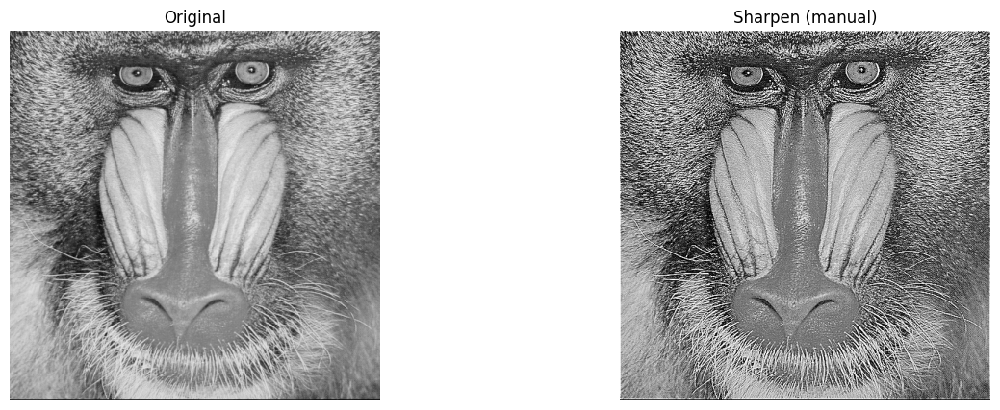

In [22]:
img = muat('mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

hasil = convolution2d(img_gray, kernel_sharpen, 1, 1)
show_side_by_side([img_gray, np.clip(hasil, 0, 255).astype(np.uint8)], ['Original', 'Sharpen (manual)'])

### Filter table


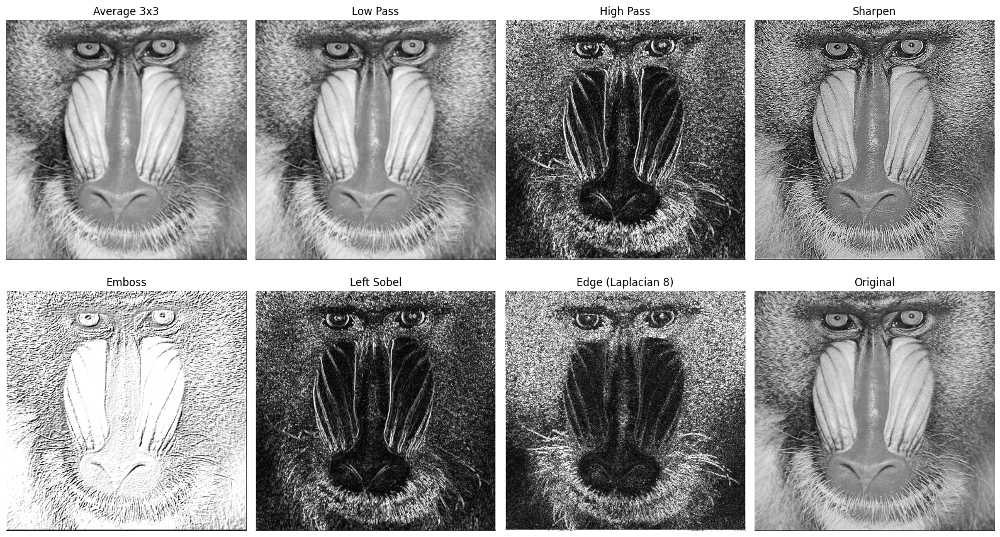

In [23]:
kernels = {
    'Average 3x3': np.ones((3, 3)) / 9,
    'Low Pass': np.array([[1, 1, 1], [1, 4, 1], [1, 1, 1]]) / 12,
    'High Pass': np.array([[-1, 0, 1], [-1, 0, 3], [-3, 0, 1]]),
    'Sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
    'Emboss': np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]]),
    'Left Sobel': np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]]),
    'Edge (Laplacian 8)': np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]),
}

edge_type = ('Left Sobel', 'Edge (Laplacian 8)', 'High Pass')

plt.figure(figsize=(16, 9))
for i, (nama, k) in enumerate(kernels.items(), 1):
    r = convolution2d(img_gray, k, 1, 1)
    r = np.abs(r) if nama in edge_type else r
    if nama == 'Emboss':
        r = r + 128
    plt.subplot(2, 4, i)
    plt.imshow(np.clip(r, 0, 255), cmap='gray')
    plt.title(nama)
    plt.axis('off')
plt.subplot(2, 4, 8)
plt.imshow(img_gray, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.tight_layout()
plt.show()

### 21x21 Gaussian blur

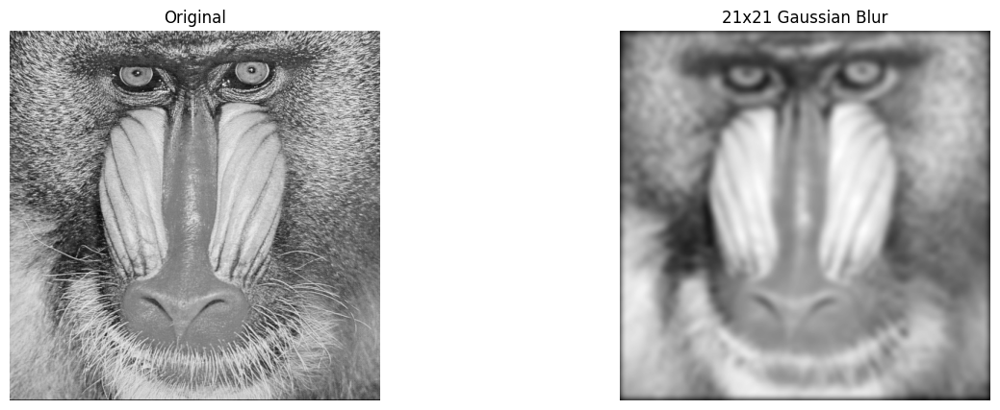

In [24]:
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.T

blur21 = convolution2d(img_gray, gauss_kernel, 1, kernel_size // 2)
show_side_by_side([img_gray, np.clip(blur21, 0, 255).astype(np.uint8)], ['Original', '21x21 Gaussian Blur'])

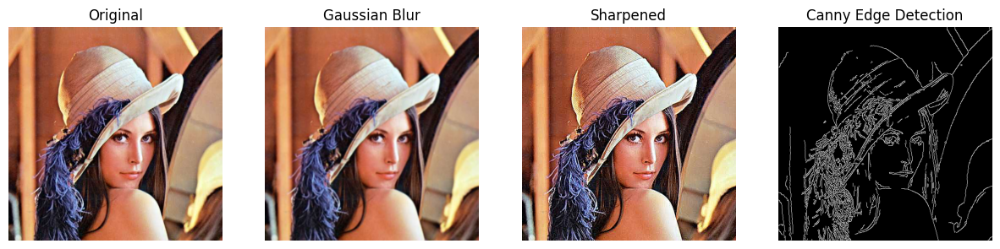

In [25]:
img = muat('lena.jpg')

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  ['Original', 'Gaussian Blur', 'Sharpened', 'Canny Edge Detection'])

## Experiment 2 - Bilateral and edge preserving


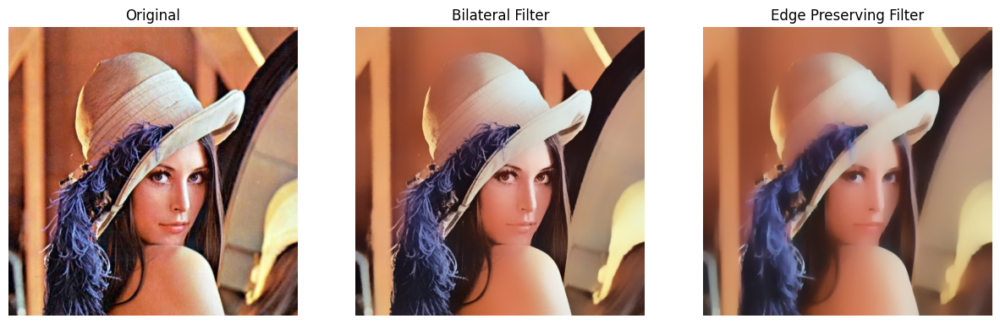

In [26]:
bilateral = cv.bilateralFilter(img, 50, 100, 100)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ['Original', 'Bilateral Filter', 'Edge Preserving Filter'])

## Experiment 3 - Feature maps


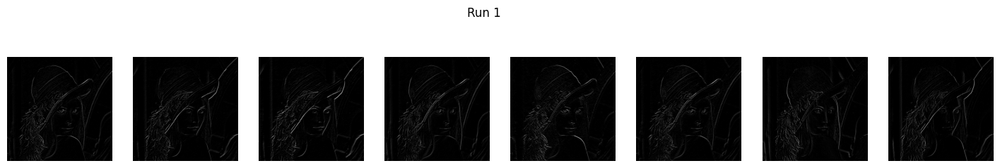

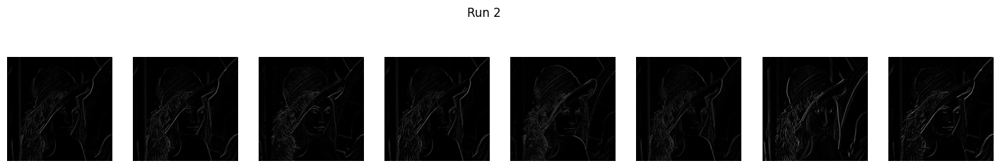

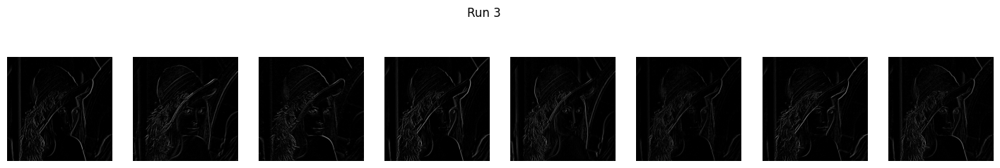

In [27]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY).astype(np.float32) / 255

def feature_maps(n=8, ukuran=3):
    maps = []
    for _ in range(n):
        k = np.random.randn(ukuran, ukuran).astype(np.float32)
        k -= k.mean()
        maps.append(np.maximum(cv.filter2D(gray, -1, k), 0))
    return maps

for percobaan in range(3):
    maps = feature_maps()
    plt.figure(figsize=(18, 3))
    for i, m in enumerate(maps, 1):
        plt.subplot(1, 8, i)
        plt.imshow(m, cmap='gray')
        plt.axis('off')
    plt.suptitle('Run ' + str(percobaan + 1))
    plt.show()

**Conclusion:** every run gives different maps because the weights are random. Some kernels react to edges in one direction, some to flat areas, some to almost nothing.

## Experiment 4 - Beauty and Vintage


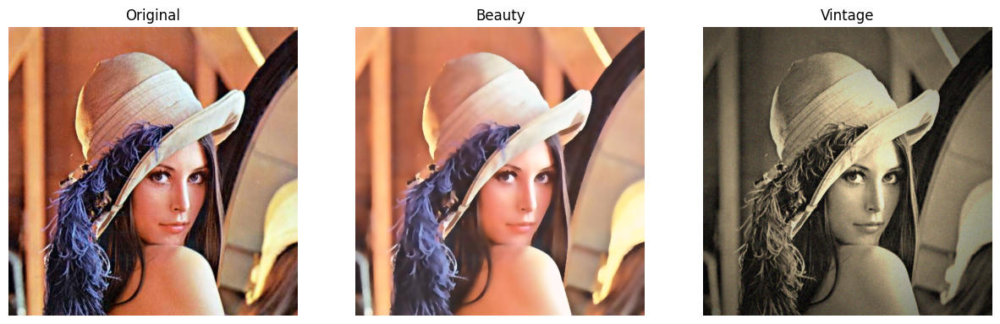

In [28]:
def beauty(image):
    halus = cv.bilateralFilter(image, 9, 75, 75)
    halus = cv.bilateralFilter(halus, 9, 75, 75)
    terang = cv.convertScaleAbs(halus, alpha=1.05, beta=12)
    hangat = np.full_like(terang, (170, 190, 255))
    return cv.addWeighted(terang, 0.9, hangat, 0.1, 0)

def vintage(image):
    sepia = np.array([[0.272, 0.534, 0.131],
                      [0.349, 0.686, 0.168],
                      [0.393, 0.769, 0.189]])
    hasil = cv.transform(image, sepia)
    hasil = cv.convertScaleAbs(hasil, alpha=0.9, beta=10)
    h, w = hasil.shape[:2]
    kx = cv.getGaussianKernel(w, w / 2)
    ky = cv.getGaussianKernel(h, h / 2)
    mask = ky @ kx.T
    mask = mask / mask.max()
    hasil = (hasil * mask[:, :, None]).astype(np.uint8)
    grain = np.random.normal(0, 8, hasil.shape)
    return np.clip(hasil + grain, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty(img), vintage(img)], ['Original', 'Beauty', 'Vintage'])

## Experiment 5 - Cartoon

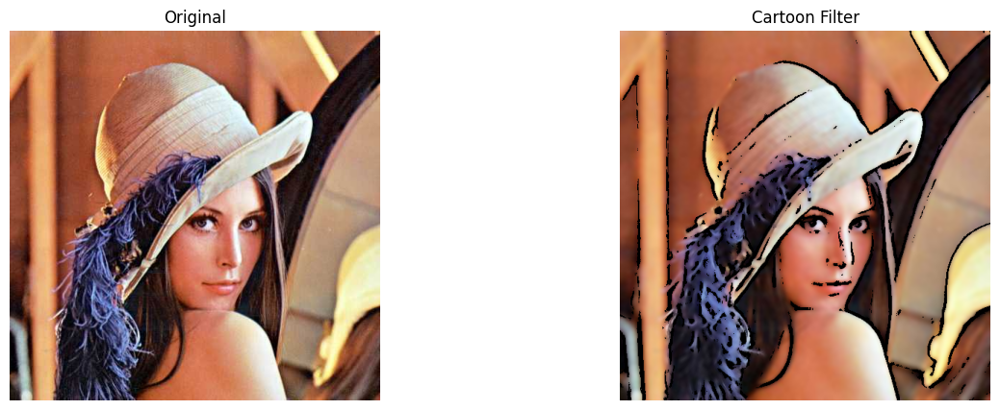

In [29]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)
cartoon_img = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon_img], ['Original', 'Cartoon Filter'])

## Experiment 6 - Night filter

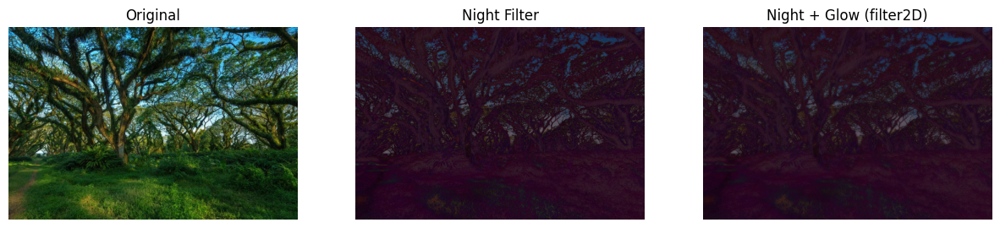

In [30]:
img_tree = muat('djawatan.jpg')

night = cv.convertScaleAbs(img_tree, alpha=0.6, beta=-40)
blue_tint = np.full_like(night, (50, 0, 100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img_tree, night, night_glow], ['Original', 'Night Filter', 'Night + Glow (filter2D)'])

## Experiment 7 - Morning and fog

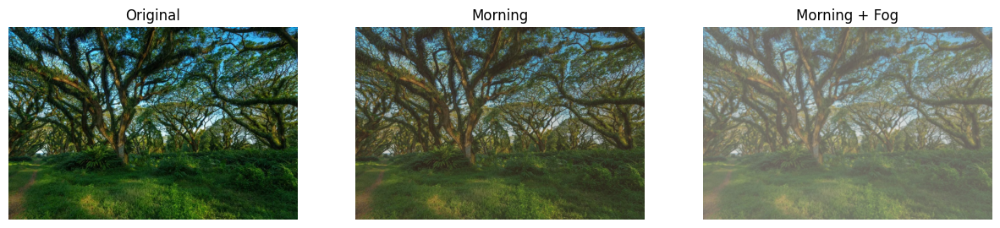

In [31]:
soft = cv.convertScaleAbs(img_tree, alpha=0.9, beta=20)
warm_tint = np.full_like(soft, (40, 70, 120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T
kabut = cv.filter2D(pagi, -1, kernel)

white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img_tree, pagi, kabut], ['Original', 'Morning', 'Morning + Fog'])

# Practicum Tasks

## Task 1 - Mean vs Median on salt and pepper noise

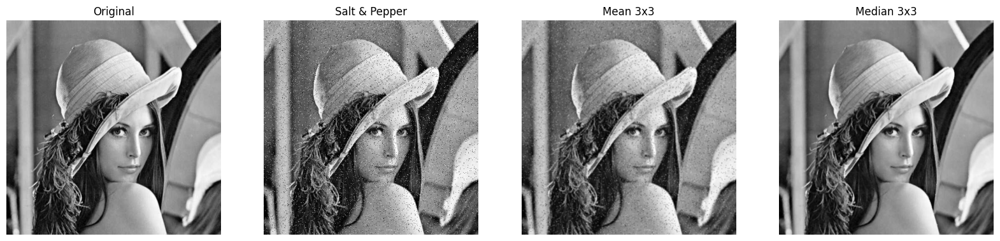

PSNR noisy  : 17.96 dB
PSNR mean   : 25.78 dB
PSNR median : 32.99 dB


In [32]:
def salt_pepper(image, amount=0.05):
    noisy = image.copy()
    rnd = np.random.rand(*image.shape)
    noisy[rnd < amount / 2] = 0
    noisy[rnd > 1 - amount / 2] = 255
    return noisy

gray = muat('lena.jpg', gray=True)
noisy = salt_pepper(gray, 0.05)
mean_f = cv.blur(noisy, (3, 3))
median_f = cv.medianBlur(noisy, 3)

show_side_by_side([gray, noisy, mean_f, median_f], ['Original', 'Salt & Pepper', 'Mean 3x3', 'Median 3x3'], figsize=(20, 5))

def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return 10 * np.log10(255.0 ** 2 / mse)

print('PSNR noisy  : %.2f dB' % psnr(gray, noisy))
print('PSNR mean   : %.2f dB' % psnr(gray, mean_f))
print('PSNR median : %.2f dB' % psnr(gray, median_f))

**Why median wins:** the mean filter averages the 9 pixels, so a white or black dot gets mixed into its neighbours and leaves a gray smudge, while the whole image also gets blurry. The median sorts the 9 values and takes the middle one.

## Task 2 - Best sharpening kernel size


3x3 | edge clarity:    101.6 | added noise: 15.95
5x5 | edge clarity:     37.0 | added noise: 3.99
blurry input | edge clarity:     13.6


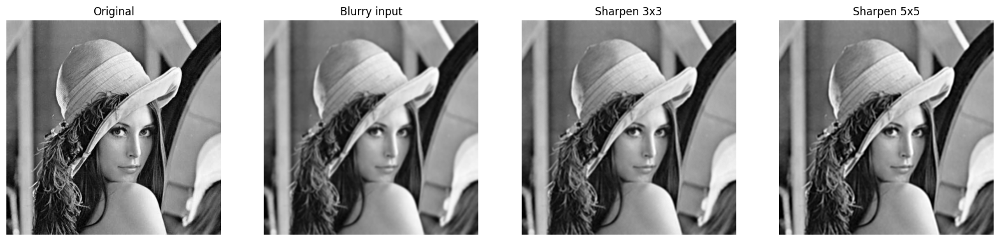

In [33]:
k3 = np.array([[0, -1, 0],
               [-1, 5, -1],
               [0, -1, 0]], dtype=np.float32)

k5 = np.array([[-1, -1, -1, -1, -1],
               [-1, 2, 2, 2, -1],
               [-1, 2, 8, 2, -1],
               [-1, 2, 2, 2, -1],
               [-1, -1, -1, -1, -1]], dtype=np.float32) / 8

asli = muat('lena.jpg', gray=True)
blurry = cv.GaussianBlur(asli, (7, 7), 2)
noise = np.random.normal(0, 3, blurry.shape)
blurry_noisy = np.clip(blurry + noise, 0, 255).astype(np.uint8)

def ketajaman(x):
    return cv.Laplacian(x, cv.CV_64F).var()

hasil = {}
for nama, k in [('3x3', k3), ('5x5', k5)]:
    bersih = cv.filter2D(blurry, -1, k)
    berisik = cv.filter2D(blurry_noisy, -1, k)
    tambahan_noise = np.std(berisik.astype(float) - bersih.astype(float))
    hasil[nama] = bersih
    print('%s | edge clarity: %8.1f | added noise: %.2f' % (nama, ketajaman(bersih), tambahan_noise))

print('blurry input | edge clarity: %8.1f' % ketajaman(blurry))

show_side_by_side([asli, blurry, hasil['3x3'], hasil['5x5']],
                  ['Original', 'Blurry input', 'Sharpen 3x3', 'Sharpen 5x5'], figsize=(20, 5))

**How to read it:** compare the two rows. If 5x5 gives more clarity but also much more added noise (and visible halos around edges), 3x3 is the safer pick for daily use. Pick based on your own numbers and zoom into the images to confirm.

## Task 3 - Cartoon function

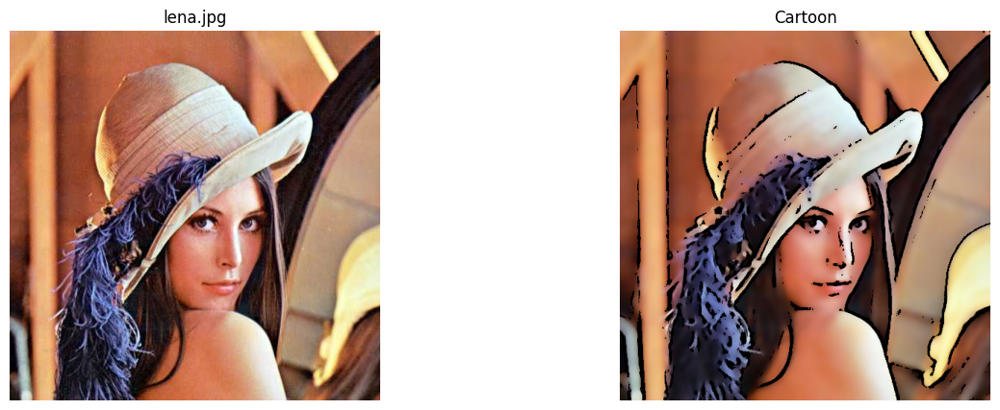

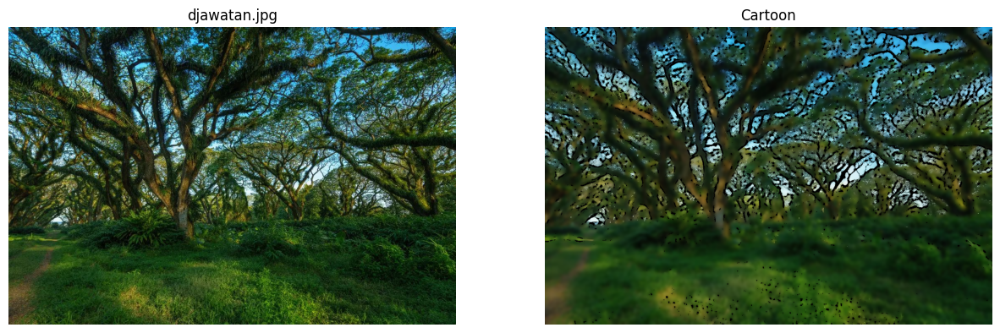

In [34]:
def cartoon(image):
    color = image
    for _ in range(3):
        color = cv.bilateralFilter(color, 9, 75, 75)
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)
    edges = cv.cvtColor(edges, cv.COLOR_GRAY2BGR) / 255.0
    return (color * edges).astype(np.uint8)

for nama in ['lena.jpg', 'djawatan.jpg']:
    foto = muat(nama)
    show_side_by_side([foto, cartoon(foto)], [nama, 'Cartoon'])